# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 

# 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [1]:
import sys
#sys.path.insert(0,'/home/storage/fortimtb/DatasetsML/Tools/')
sys.path.insert(0,'/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
dataset = 'Cr-Co-W/'
from Tools.DatasetTools.EVCurvesTools import *
from BopFoxFeaturizer.Featurizer import Featurizer
import pickle


import os

In [2]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

## Investigate ev-curves

In [3]:
evcurvesloc = os.path.join(dataset,'evcurves.json' )
if not os.path.exists(evcurvesloc):
    EV = Evcurves(atoms=['Cr','Co','W'], dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
    EV.load_evcurves(PBS.index, deltaks = PBS['deltak'], encuts = PBS['encut'])
    EV.evcurves.to_json(evcurvesloc)
EVcurves = pd.read_json(evcurvesloc, typ='series') 
goodness, fiteos, r2  = get_goodness(EVcurves)         
#plot_curves (goodness, EVcurves, 'multipage_fitted_curves.pdf')
#plot_curves (invert_goodness(goodness), EVcurves, 'multipage_bad_curves.pdf')

  0%|          | 0/1834 [00:00<?, ?it/s]

In [4]:
goodness

Co_pv6W_sv6.C14-BBA.FM                 {'xc=PBE-PAW.E=400.dk=0.020': True}
Co_pv6W_sv6.C14-BBA.NM                 {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv6W_sv2.D0_19-A3B.FM               {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv6W_sv2.D0_19-A3B.NM               {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM     {'xc=PBE-PAW.E=400.dk=0.020': True}
                                                      ...                 
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM      {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM      {'xc=PBE-PAW.E=400.dk=0.020': True}
Co_pv13W_sv16.chi-ABAB.NM              {'xc=PBE-PAW.E=400.dk=0.020': True}
Co_pv13W_sv16.chi-ABAB.FM             {'xc=PBE-PAW.E=400.dk=0.020': False}
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM     {'xc=PBE-PAW.E=400.dk=0.020': True}
Length: 1834, dtype: object

In [5]:
indexofgoodsamples = pd.Index([theindex for theindex, thecurve in goodness.items() if True in thecurve.values()])
GoodBS = PBS.loc[indexofgoodsamples]
BadBS = PBS.loc[PBS.index.difference(indexofgoodsamples)]

## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [6]:
GoodBS = GoodBS.loc[~GoodBS.index.str.contains('\..*[UD]+$') ]

In [7]:
GoodBS.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
Index: 1701 entries, Co_pv6W_sv6.C14-BBA.FM to Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM
Columns: 19 entries,  to num_atoms
dtypes: float64(4), int64(1), object(14)
memory usage: 265.8+ KB


## Obtain some info from indexes

In [8]:
Features = Featurizer(GoodBS)

## translate structures to their bases

# TODo this sould be in tools, as a phase cleaner

In [9]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    GoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=GoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [10]:
Target_Class

Co_pv6W_sv6.C14-BBA.FM                  C14
Co_pv6W_sv6.C14-BBA.NM                  C14
Cr_pv6W_sv2.D0_19-A3B.FM                hcp
Cr_pv6W_sv2.D0_19-A3B.NM                hcp
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM    sigma
                                      ...  
Cr_pv10W_sv3.mu-BAAAB.FM                 mu
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM     sigma
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM     sigma
Co_pv13W_sv16.chi-ABAB.NM               chi
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.NM    sigma
Length: 1701, dtype: object

In [11]:
GoodBS['Phase'] = Target_Class

In [12]:
GoodBS.describe()

,E0,nelem,B0,V0,num_atoms,Co_pv,Cr_pv,W_sv
count,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000,1701.000000
mean,-9.585216,2.541446,250.548597,13.203339,21.965315,0.323785,0.340741,0.335473
std,1.188574,0.561682,22.528036,1.499822,8.686398,0.244977,0.250990,0.243910
min,-12.953686,1.000000,104.539707,10.314702,1.000000,0.000000,0.000000,0.000000
25%,-10.378787,2.000000,237.019893,11.955027,13.000000,0.153846,0.153846,0.153846
50%,-9.524625,3.000000,252.629633,13.059967,24.000000,0.307692,0.333333,0.307692
75%,-8.758552,3.000000,264.325020,14.353720,30.000000,0.500000,0.533333,0.500000
max,-6.504079,3.000000,458.517772,16.955051,53.000000,1.000000,1.000000,1.000000


# Save for later use 

In [13]:
curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
GoodBS.to_pickle(curatedbs)

# some E-V curves, good and bad

In [14]:
sample_bad = EVcurves[BadBS.index].dropna().sample(n=5)

In [15]:
sample_bad

Cr_pv2Co_pv11.mu-BBBBA.FM          {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv1Co_pv28.chi-ABBB.FM          {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv4Co_pv2W_sv6.C14-BCA.FM       {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv8Co_pv6W_sv10.C36-AACBC.FM    {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv4W_sv8.C14-ABB.FM             {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
dtype: object

In [16]:
goodness[sample_bad.index]

Cr_pv2Co_pv11.mu-BBBBA.FM          {'xc=PBE-PAW.E=400.dk=0.020': False}
Cr_pv1Co_pv28.chi-ABBB.FM          {'xc=PBE-PAW.E=400.dk=0.020': False}
Cr_pv4Co_pv2W_sv6.C14-BCA.FM       {'xc=PBE-PAW.E=400.dk=0.020': False}
Cr_pv8Co_pv6W_sv10.C36-AACBC.FM    {'xc=PBE-PAW.E=400.dk=0.020': False}
Cr_pv4W_sv8.C14-ABB.FM             {'xc=PBE-PAW.E=400.dk=0.020': False}
dtype: object

In [17]:
sample_bad_r2 = r2[sample_bad.index]

In [18]:
sample_bad_fit = fiteos[sample_bad.index]

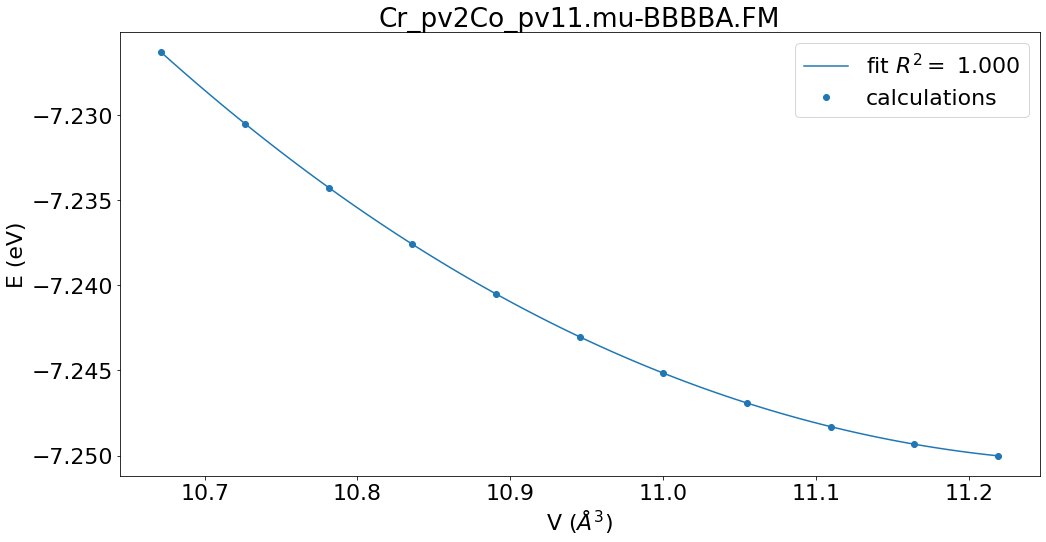

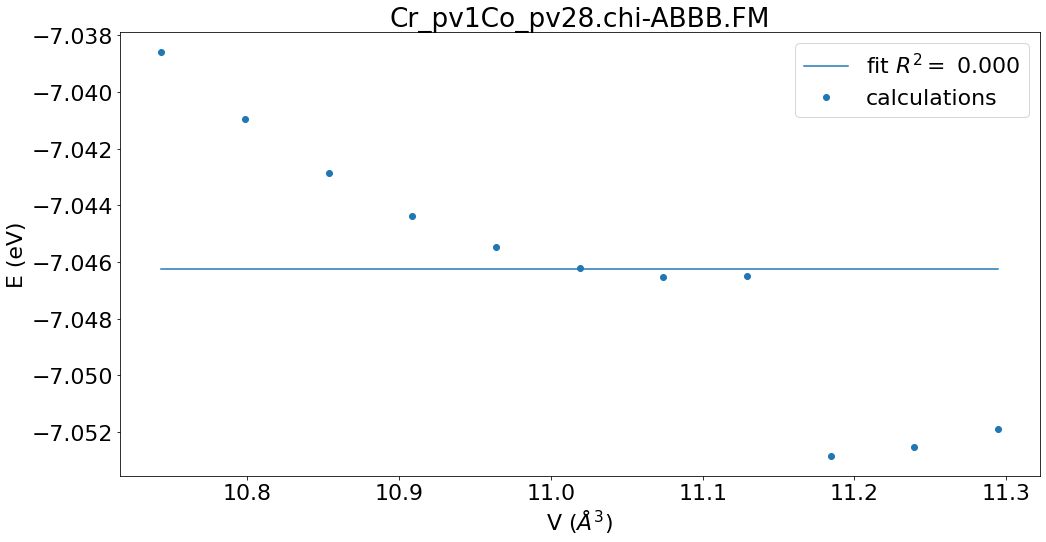

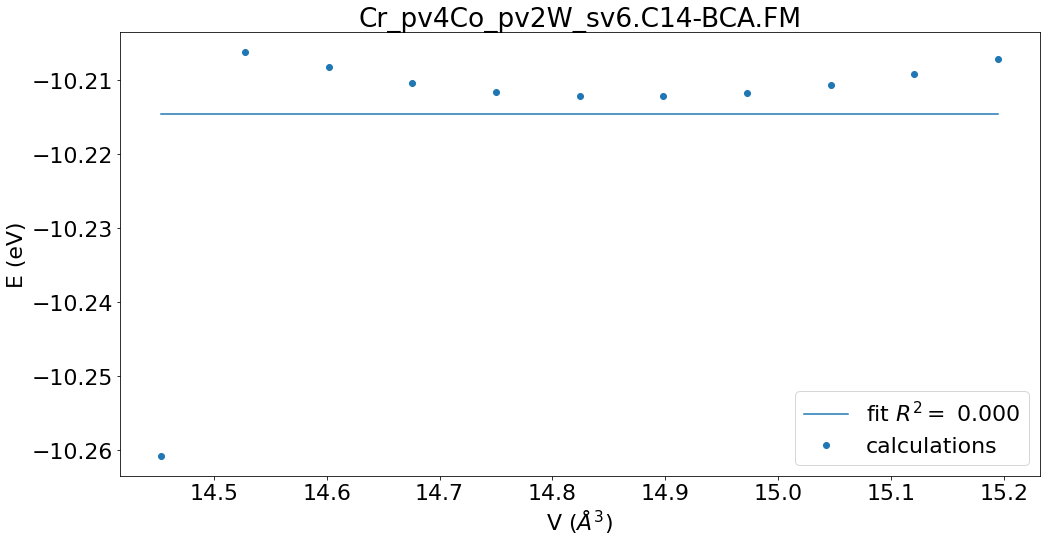

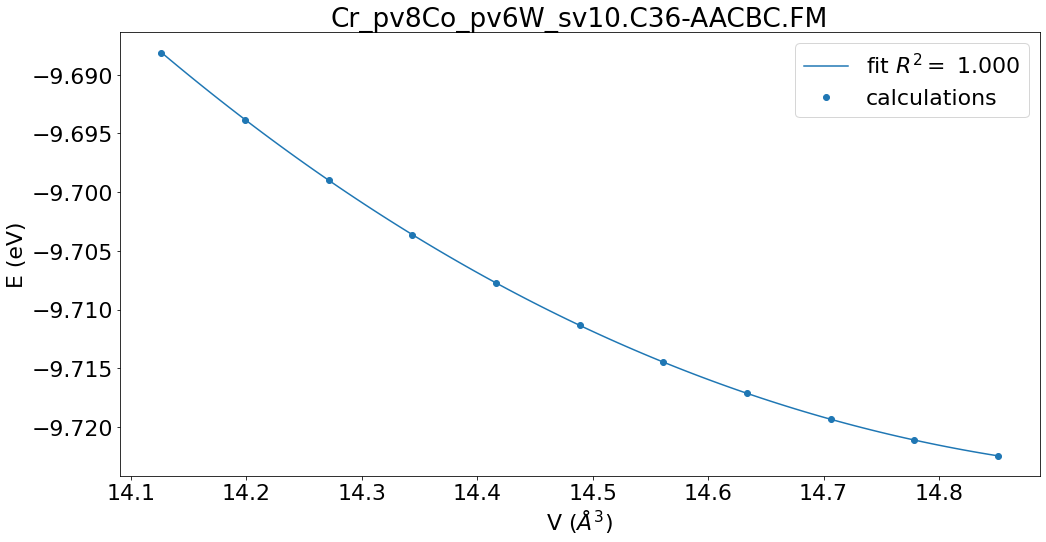

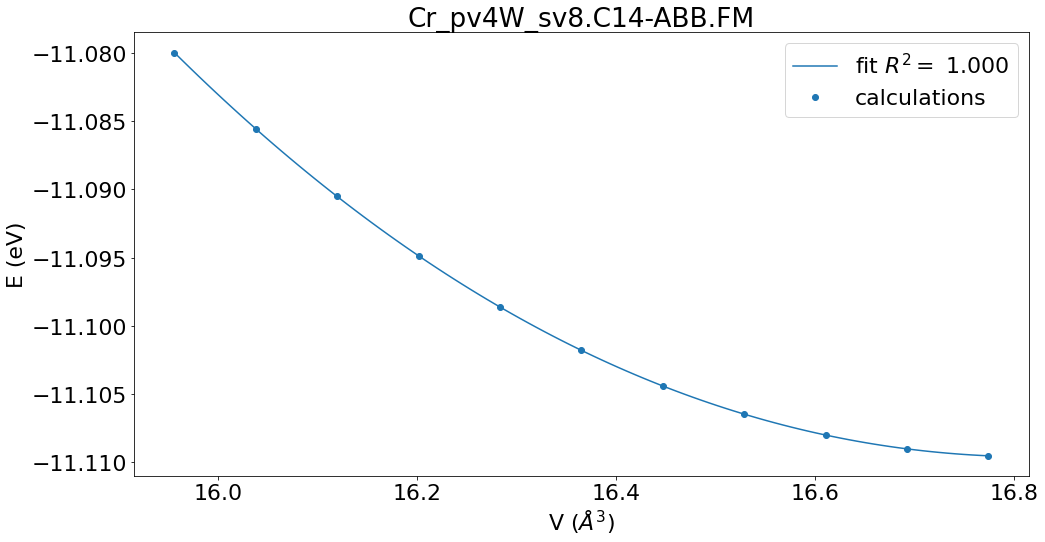

In [19]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)

In [20]:
sample_good = EVcurves[GoodBS.index].dropna().sample(n=5)

In [21]:
sample_good

Cr_pv10W_sv20.sigma-ABABB.NM     {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv2W_sv11.mu-BBABB.NM         {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Co_pv4W_sv9.mu-BBAAB.NM          {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Co_pv2W_sv6.A15-BA.FM            {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
Cr_pv14Co_pv16.sigma-AABAB.NM    {'xc=PBE-PAW.E=400.dk=0.020': {'evcurve': {'V'...
dtype: object

In [22]:
goodness[sample_good.index]

Cr_pv10W_sv20.sigma-ABABB.NM     {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv2W_sv11.mu-BBABB.NM         {'xc=PBE-PAW.E=400.dk=0.020': True}
Co_pv4W_sv9.mu-BBAAB.NM          {'xc=PBE-PAW.E=400.dk=0.020': True}
Co_pv2W_sv6.A15-BA.FM            {'xc=PBE-PAW.E=400.dk=0.020': True}
Cr_pv14Co_pv16.sigma-AABAB.NM    {'xc=PBE-PAW.E=400.dk=0.020': True}
dtype: object

In [23]:
sample_good_r2 = r2[sample_good.index]

In [24]:
sample_good_fit = fiteos[sample_good.index]

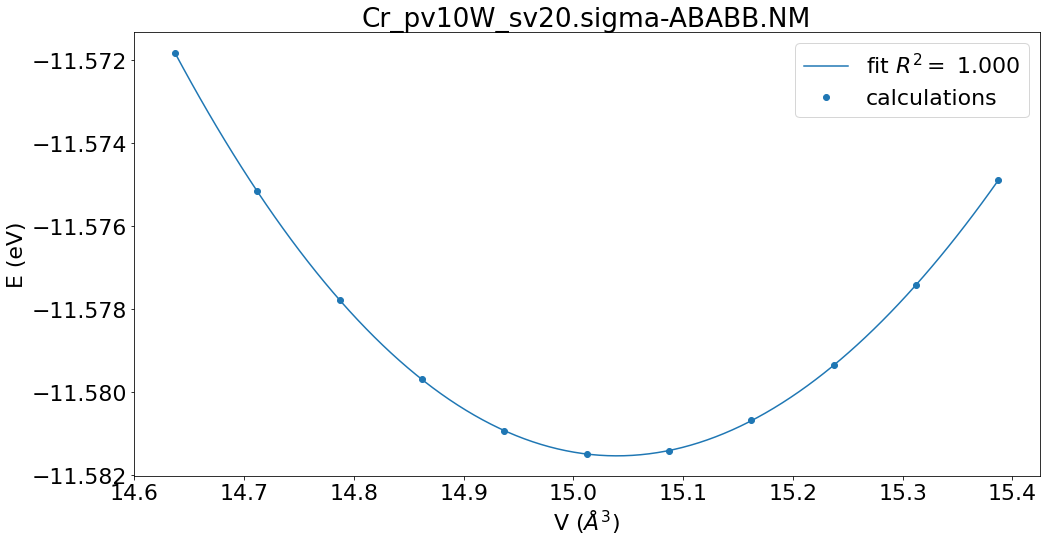

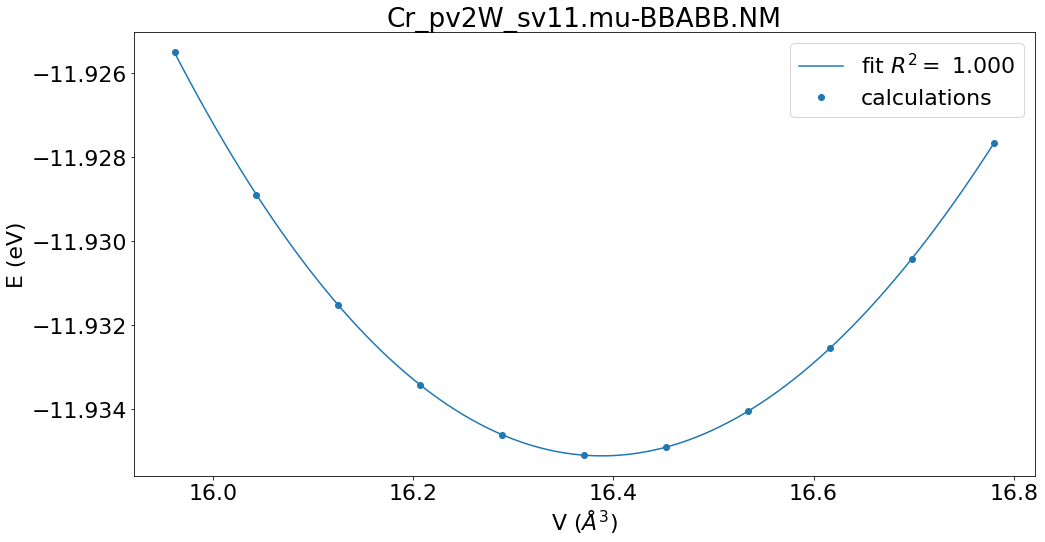

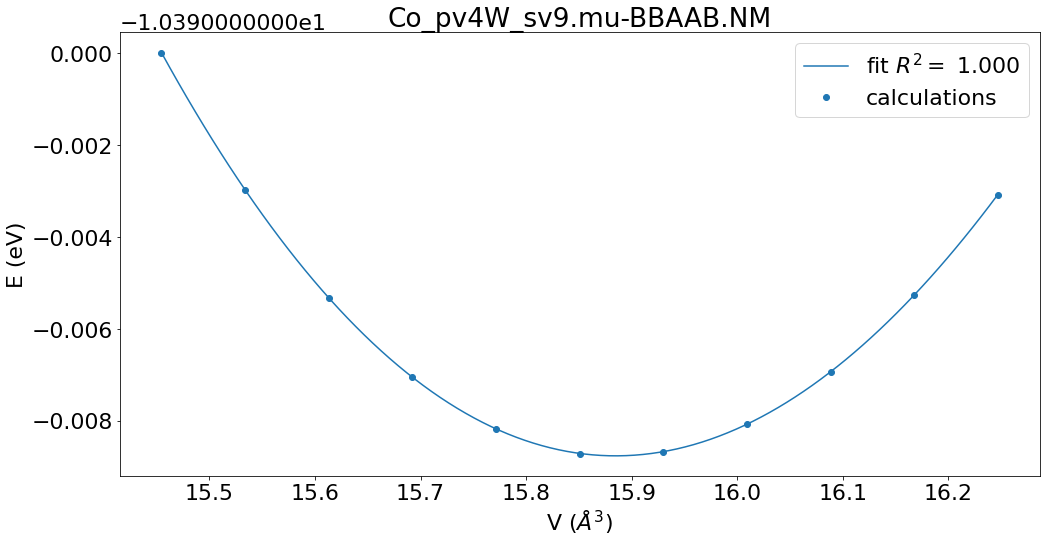

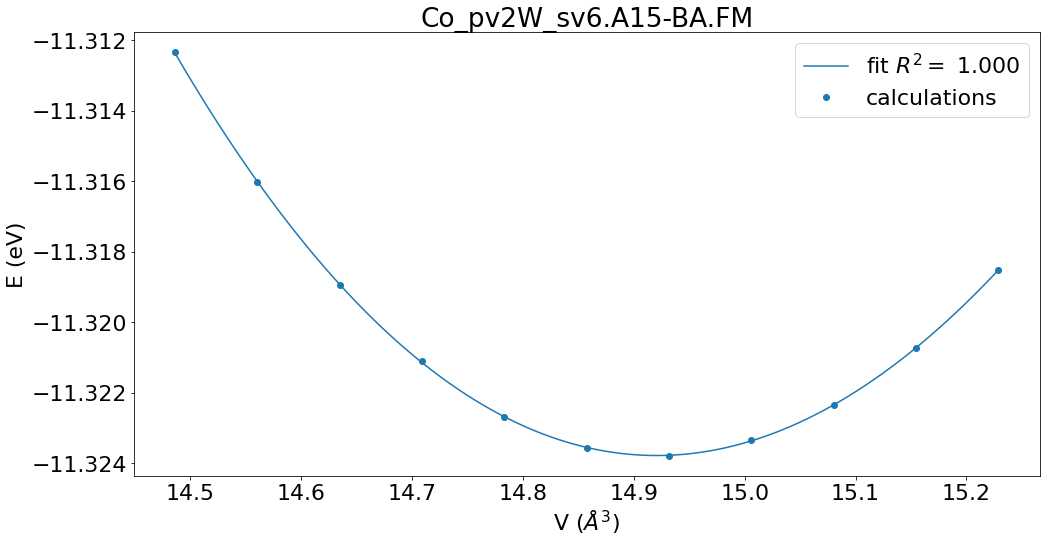

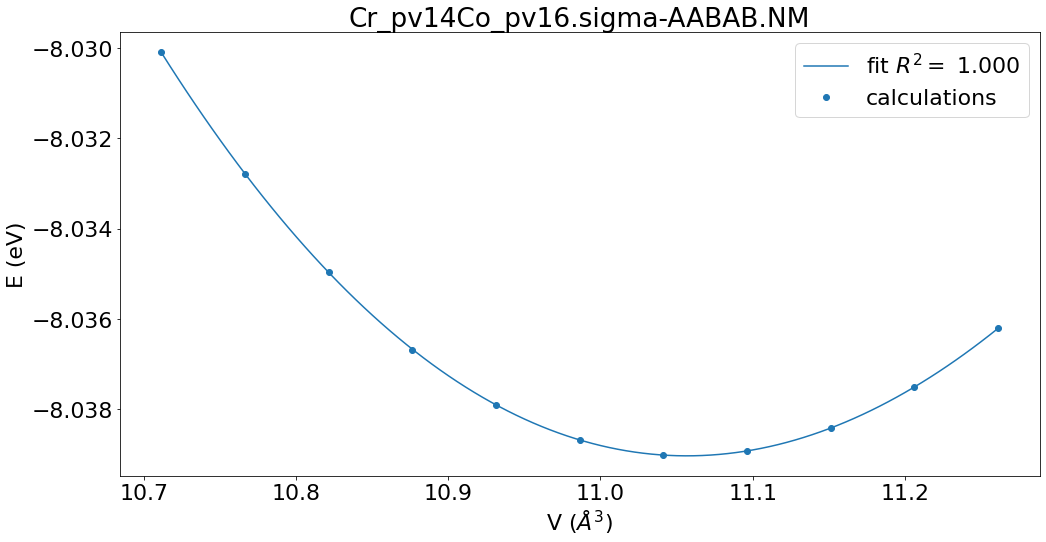

In [25]:
figurecollection, axcollection  = plot_curves(sample_good, sample_good_fit, sample_good_r2)